In [2]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import glasbey
import os
import h5py
import numpy as np
from sklearn.decomposition import PCA
import openTSNE # add this

pio.renderers.default = 'browser'

In [ ]:
# read in matlab output
mat_filename = r"gibberish"

# "C:\Users\gangliagurdian\Desktop\Mias Folder\data testing\10min testing\Combined_Results\Results\test1\session_1_out.mat"
# "Z:\socialbox_fp\C2_042125_C3_042125_gpe\C2_042125\042125_1\open_field_061625\day_1\042125_1_tdt_rt_061625of\Bonsai - Copy\AccelCluster_Output - Copy\Combined_Results\Results\test1\session_1_out.mat"

In [9]:
# extract similarity matrix & cluster labels
if os.path.exists(mat_filename):
    with h5py.File(mat_filename, 'r') as file:
        clusters = file['Clusters']
        similarity_matrix = clusters['sim'][()]

        cluster_labels = clusters["idx"][()]
else:
    raise FileNotFoundError('Could not find session_1_out.mat in dedicated subdirectory')

print(similarity_matrix.shape)
print(cluster_labels.shape)

# transpose cluster_labels
cluster_labels = cluster_labels.T

# turn clusters_labels into 1D array
cluster_labels = cluster_labels.flatten()
print(cluster_labels.shape)

(47673, 47673)
(1, 47673)
(47673,)


In [10]:
# apply PCA to reduce dimensions to 50
pca = PCA(n_components=50)
similarity_matrix_reduced = pca.fit_transform(similarity_matrix)
pd.DataFrame(similarity_matrix_reduced).to_csv("similarity_matrix_reduced.csv", index=False)
print(similarity_matrix_reduced.shape)

(47673, 50)


In [44]:
similarity_matrix_reduced = pd.read_csv("similarity_matrix_reduced.csv").values

In [ ]:
subset_indices = np.random.choice(range(len(similarity_matrix_reduced)), size=int(len(similarity_matrix_reduced)*0.5))  
subset_indices

array([20467, 40952, 46294, ...,  1978,  8702, 23514], shape=(23836,))

In [88]:
cluster_details = pd.read_csv(r"X:\3darena_chemogenetic\c1_041626\042126_m2_dls\cluster_ouput_042126_m2_dls+LargeOF+High_Tier\Combined_Results\Results\test1\Cluster_detail_results.csv")
cluster_labels = cluster_details["ClusterIdx"].values

In [50]:
shared = [1, 2, 25, 29, 38, 45, 58]
openf = [9, 22, 23, 35, 37, 39]
hight = [14, 64,7, 24, 40, 48, 4, 20, 27, 19, 3, 5, 50, 56, 59, 11]

In [107]:
cluster_details["Condition"] = np.where(cluster_details["ClusterIdx"].isin(shared), "Shared", "Unknown")
cluster_details["Condition"] = np.where(cluster_details["ClusterIdx"].isin(openf), "Open Field", cluster_details["Condition"])
cluster_details["Condition"] = np.where(cluster_details["ClusterIdx"].isin(hight), "High Tier", cluster_details["Condition"])
cluster_details["Condition"]

0         Shared
1         Shared
2         Shared
3         Shared
4         Shared
          ...   
47668    Unknown
47669    Unknown
47670    Unknown
47671    Unknown
47672    Unknown
Name: Condition, Length: 47673, dtype: str

In [108]:
cluster_details

,ClusterIdx,Timestamp,Folder_Name,Condition
0,1,4965.2413,1_baseline_largeof,Shared
1,1,4965.5412,1_baseline_largeof,Shared
2,1,4965.8410,1_baseline_largeof,Shared
3,1,4966.1409,1_baseline_largeof,Shared
4,1,4966.4407,1_baseline_largeof,Shared
...,...,...,...,...
47668,61,21183.2658,4_inhibition_hight,Unknown
47669,61,21183.6158,4_inhibition_hight,Unknown
47670,62,21183.9758,4_inhibition_hight,Unknown
47671,31,21184.3208,4_inhibition_hight,Unknown


In [109]:
cluster_labels_str = [str(c) for c in cluster_labels]
cluster_names = sorted(set(cluster_labels_str))

condition_labels_str = cluster_details["Condition"].values
condition_names = sorted(set(condition_labels_str))

import glasbey
glasbey_palette = glasbey.create_palette(palette_size=len(cluster_names))
cluster_to_color = {
    name: glasbey_palette[i]
    for i, name in enumerate(cluster_names)
}


condition_to_color = {
    "Unknown": "#7a7a7a",  # gray for unknown
    "Shared": "#3fd444",  # bright green for shared
    "Open Field": "#5c95db",  # bright blue for open field
    "High Tier": "#e83a3a",  # bright red for high tier
}

def plot_single(data, title=None, **kwargs):
    fig = px.scatter(
        x=data[:, 0],
        y=data[:, 1],
        color=cluster_labels_str,
        title=title or 'openTSNE Multiscale Visualization',
        color_discrete_map=cluster_to_color,
        labels={'x': 't-SNE 1', 'y': 't-SNE 2'}
    )

    
    print(f"Embedding shape: {data.shape}")

    fig.update_traces(marker=dict(size=5))
    
    fig.update_layout(width=1200, height=1000)
    fig.write_image(f"{title.replace(" ", "_")}.png")
    fig.show()

In [54]:
# %%time
# embedding_standard = openTSNE.TSNE( # Standard t-SNE with openTSNE
#     perplexity=30,
#     initialization="random",
#     metric="euclidean",
#     n_jobs=-1,
#     random_state=3,
# ).fit(similarity_matrix_reduced)

# plot_single(embedding_standard)

In [ ]:
%%time
affinities_multiscale_mixture = openTSNE.affinity.Multiscale(
    similarity_matrix_reduced,
    perplexities=[50, 500],
    metric="cosine",
    n_jobs=-1,
    random_state=3,
)
# multiscale 

%time init = openTSNE.initialization.pca(similarity_matrix_reduced, random_state=42)

CPU times: total: 5min 50s
Wall time: 2min 50s


In [ ]:


embedding_multiscale = openTSNE.TSNE(n_jobs=-1).fit(
    affinities=affinities_multiscale_mixture,
    initialization=init,
)
pd.DataFrame(embedding_multiscale).to_csv("embedding_multiscale.csv", index=False)

CPU times: total: 31.2 ms
Wall time: 26.1 ms


In [103]:
def plot_gen_single(data, cond_labels, title="openTSNE Multiscale Visualization", **kwargs):
    fig = px.scatter(
        x=data[:, 0],
        y=data[:, 1],
        color=cond_labels,
        title=title,
        color_discrete_map=condition_to_color,
        labels={'x': 't-SNE 1', 'y': 't-SNE 2'}
    )

    print(f"Embedding shape: {data.shape}")

    fig.update_traces(marker=dict(size=5))
    fig.update_layout(width=1200, height=1000)
    fig.write_image(f"{title.replace(" ", "_")}.png")
    fig.show()

def get_cond_labels(cluster_details: pd.DataFrame, indices: list):
    cluster_details = cluster_details.loc[indices]

    cluster_details["Condition"] = np.where(cluster_details["ClusterIdx"].isin(shared), "Shared", "Unknown")
    cluster_details["Condition"] = np.where(cluster_details["ClusterIdx"].isin(openf), "Open Field", cluster_details["Condition"])
    cluster_details["Condition"] = np.where(cluster_details["ClusterIdx"].isin(hight), "High Tier", cluster_details["Condition"])
    return cluster_details["Condition"]

In [104]:
cluster_details = pd.read_csv(r"X:\3darena_chemogenetic\c1_041626\042126_m2_dls\cluster_ouput_042126_m2_dls+LargeOF+High_Tier\Combined_Results\Results\test1\Cluster_detail_results.csv")
Conditions = {
    "All": np.array([True for _ in range(len(cluster_details))]),
    "Baseline": cluster_details["Folder_Name"].str.contains("baseline"), 
    "Inhibition": cluster_details["Folder_Name"].str.contains("inhibition"),
    "Baseline Open Field": cluster_details["Folder_Name"].str.contains("baseline_largeof"),
    "Baseline High Tier": cluster_details["Folder_Name"].str.contains("baseline_hight"),
    "Inhibition Open Field": cluster_details["Folder_Name"].str.contains("inhibition_largeof"),
    "Inhibition High Tier": cluster_details["Folder_Name"].str.contains("inhibition_hight"),
    "High Tier": cluster_details["Folder_Name"].str.contains("hight"),
    "Open Field": cluster_details["Folder_Name"].str.contains("largeof"),
}


In [105]:
for condition, mask in Conditions.items():
    indices = cluster_details.index[mask]
    cond_labels = get_cond_labels(cluster_details, indices)
    embedding_multiscale_subset = embedding_multiscale[indices]
    plot_gen_single(embedding_multiscale_subset, cond_labels, title=f"openTSNE Multiscale Visualization - {condition}")

Embedding shape: (47673, 2)
Embedding shape: (23823, 2)
Embedding shape: (23713, 2)
Embedding shape: (11871, 2)
Embedding shape: (11952, 2)
Embedding shape: (11802, 2)
Embedding shape: (11911, 2)
Embedding shape: (23863, 2)
Embedding shape: (23673, 2)


In [72]:
cluster_details.index[cluster_details["Folder_Name"].str.contains("baseline")]

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       23865, 23866, 23867, 23868, 23869, 23870, 23871, 23872, 23873, 23874],
      dtype='int64', length=23823)

In [110]:

plot_single(embedding_multiscale, title=f"openTSNE Multiscale Visualization By Cluster")

Embedding shape: (47673, 2)


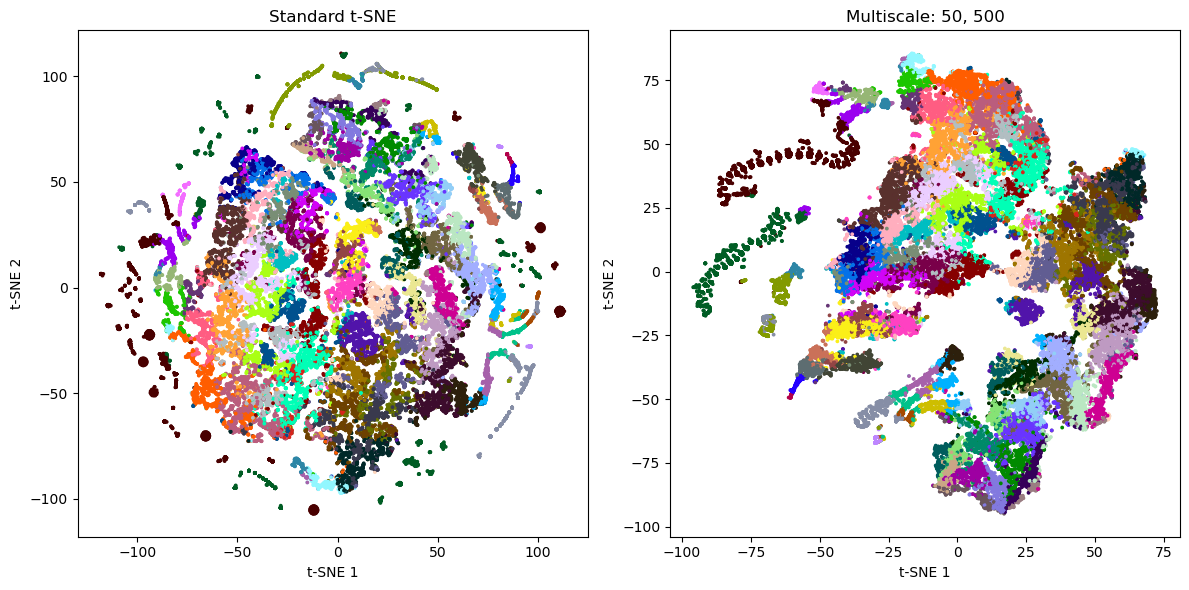

In [ ]:
# import matplotlib.pyplot as plt

# def plot(data, ax, title):
#     colors = [cluster_to_color[c] for c in cluster_labels_str]

#     ax.scatter(
#         data[:, 0],
#         data[:, 1],
#         c=colors,
#         s=3
#     )

#     ax.set_title(title)
#     ax.set_xlabel("t-SNE 1")
#     ax.set_ylabel("t-SNE 2")


# fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# plot(embedding_standard, ax[0], "Standard t-SNE")
# plot(embedding_multiscale, ax[1], "Multiscale: 50, 500")

# plt.tight_layout()
# plt.show()